# Assignment 1: Building an MLP from Scratch

In the lab, we built a small network to solve XOR. In this assignment, you will take that knowledge further and apply it to a real classification problem: the **moons dataset**.

**Rules:**
- You may **not** use PyTorch, TensorFlow, Keras, or any automatic differentiation library.
- You **may** use NumPy, Matplotlib, and scikit-learn (for data generation only).
- All gradient computations must be written by hand, following the same pattern as the lab.
- You **may** use LLMs (e.g. ChatGPT, Gemini), but any code written with their help must be clearly marked with a comment: `# AI-assisted`. Unmarked use of AI-generated code, or answers to the written questions that show no genuine understanding, may result in an oral examination.

**Deliverable:** This completed notebook. Every code cell should have been run, and every question marked with ✏️ should contain your written response.


## 1. Data

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
np.random.seed(1)


X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1000, 2)
y shape: (1000, 1)


The helper functions below are provided for you. You do not need to modify them.

In [3]:
# --- Activation functions ---
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    return x * (1 - x)

def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - x ** 2

# --- Plotting functions ---
def plot_loss(losses):
    iters, vals = zip(*losses)
    plt.figure(figsize=(7, 4))
    plt.plot(iters, vals)
    plt.xlabel("Iteration")
    plt.ylabel("Error")
    plt.title("Training Loss")
    plt.grid(True)
    plt.show()

def plot_dataset(X, y):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm', edgecolors='k', s=20)
    plt.title("dataset")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def plot_decision_boundary(X, y, W1, W2, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid  = np.c_[xx.ravel(), yy.ravel()]
    a1    = sigmoid(np.dot(grid, W1))
    a2    = sigmoid(np.dot(a1,   W2))
    probs = a2.reshape(xx.shape)
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, probs, levels=50, cmap='coolwarm', alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm', edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


### ✏️ Question 1.1

Plot at the dataset. Is it linearly separable? Could a single perceptron (no hidden layer) solve this? Why or why not?

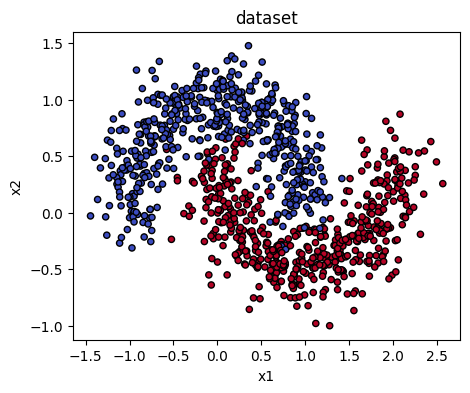

In [8]:
plot_dataset(X, y)


## 2. Initialise the Weights

Following the same pattern as the lab, write a function that initialises two weight matrices W1 and W2. You need to decide on the number of neurons for each layer yourself, justify your choice below.


In [4]:
def init_weights(input_size, hidden_size, output_size):
    __________
    __________
    return W1, W2

W1, W2 = init_weights(input_size=_____, hidden_size=_____, output_size=_____)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)


NameError: name '_____' is not defined

### ✏️ Question 2.1

What number of neurons did you choose, and why? What do you think would happen if the hidden layer size were much smaller? Much larger?

## 3. Forward Pass

Write a function that takes X, W1, and W2 and returns the hidden activations a1 and output activations a2.


In [5]:
def forward(X, W1, W2):
    __________
    __________
    return a1, a2
    

## 4. Backward Pass

Write a function that takes X, y, the activations, the weight matrices, and the learning rate, and returns the updated W1 and W2 after one gradient descent step.


In [6]:
def backward(__________):
    a2_error = __________
    a2_delta = __________
    __________
    __________
    __________
    __________
    return W1, W2


## 5. Training Loop

Using your `forward` and `backward` functions, write the training loop.


In [7]:
np.random.seed(1)
W1, W2 = init_weights(__________)

lr = __________
losses = []

for j in range(50000):
    __________  # Forward
    
    a2_error = y - a2
    if j % 2500 == 0:
        loss = np.mean(np.abs(a2_error))
        print(f"Iteration {j:5d} | Error: {loss:.4f}")
        losses.append((j, loss))

    __________  # Backward


NameError: name '__________' is not defined

Plot the loss curve:

In [8]:
plot_loss(losses)
plot_decision_boundary(X, y, W1, W2)


NameError: name 'losses' is not defined


### ✏️ Question 5.1

Describe your loss curve. Does it converge smoothly? What would you change to improve training?


In [ ]:

*Your answer here.*


### ✏️ Question 5.2

Describe the decision boundary. Does it match the shape of the data?


## 6. Large learning rate

Keep the original architecture and initialisation, but set `lr = 10.0`.

In [ ]:
# Space for your code, you can copy & paste from before and just adjust the learning rate


### ✏️ Question 6.1: 

Describe what the loss curve looks like. Does the model converge? Why does a very large learning rate cause this behaviour?


## 7. A New Dataset: Blobs

Below, a new dataset is loaded for you. Your neural network code does not need to change, but your hyperparameters might.


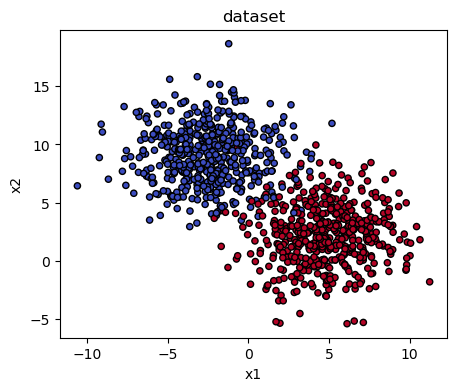

In [4]:
from sklearn.datasets import make_blobs
np.random.seed(1)

X_b, y_b = make_blobs(n_samples=1000, centers=2, cluster_std=2.5, random_state=42)
y_b = y_b.reshape(-1, 1)

plot_dataset(X_b, y_b)


Set your hyperparameters in the cell below, then run the training loop and report what you find.

In [ ]:
hidden_size_b = _____
lr_b          = _____
epochs_b      = _____


In [ ]:
np.random.seed(1)
W1_b, W2_b = init_weights(input_size=2, hidden_size=hidden_size_b, output_size=1)

losses_b = []

for j in range(epochs_b):
    __________  # Forward
    
    a2_error = y_b - a2
    if j % 2500 == 0:
        loss = np.mean(np.abs(a2_error))
        print(f"Iteration {j:5d} | Error: {loss:.4f}")
        losses_b.append((j, loss))
    
    __________ # Backward

plot_loss(losses_b)
plot_decision_boundary(X_b, y_b, W1_b, W2_b, title="Decision Boundary")


### ✏️ Question 7.1

What hyperparameters did you end up with for the blobs dataset? 

Did you need to change anything compared to the moons dataset, and why?

### ✏️ Question 7.2

Compare the decision boundaries of the two datasets.

What does this tell you about the kind of problem each network had to learn?